# Statistical Sampling: Populations , Sampels and Bias

Covers sampling theory and methods in data science, covering simple random sampling, stratified sampling, cluster sampling, sampling error.

## 1. Sampling: From Populations to Observations

Sampling is the process of selecting a subset of observations from a larger population to make inferences about the whole. It forms the foundation of statistical inference, enabling you to draw meaningful conclusions from manageable amounts of data without requiring complete enumeration of entire populations.

## 2. Introduction

In most real-world scenarios, examining every member of a population is impractical, prohibitively expensive, or simply impossible. Consider attempting to measure the average height of all adults in a country, test the quality of every product manufactured in a factory, or survey every customer who has ever used a service. Sampling provides a practical alternative by allowing us to study a carefully selected subset and use statistical methods to generalize our findings to the broader population.

The quality of insights derived from data analysis depends on how well the sample represents the population of interest. A poorly designed sampling strategy can introduce biases that invalidate conclusions, regardless of how sophisticated the subsequent analysis may be. This chapter explores the fundamental concepts of sampling, including the distinction between populations and samples, various sampling methodologies, and the inherent uncertainty that arises when working with sample data rather than complete populations.

Understanding sampling theory equips anyone who works with data to design better studies, interpret results more accurately, and recognize when conclusions drawn from data may be questionable due to sampling limitations. These skills prove essential whether collecting new data or working with existing datasets where the sampling mechanism affects what conclusions can be drawn.



## 2. Population Vs Sample

At the heart of sampling theory lies the distinction between a population and a sample. The **population** represents the complete set of all individuals, items, or observations about which we want to draw conclusions. This might be all registered voters in a country, every transaction in a database, or all possible measurements from a manufacturing process. The population defines the scope of our inference: *the group to which our conclusions should apply*.

In contrast, a **sample** consists of the subset of observations we collect and analyze. When we survey 1,000 voters from a population of millions, conduct quality tests on 100 products from a production run of 10,000, or analyze data from 500 customers out of a customer base of 100,000, we are working with samples. *The sample is a window into the population*.

Population characteristics are described by **parameters**, which are fixed but typically unknown values such as the true population mean (μ) or population proportion (p). Sample characteristics are described by statistics, which are calculated values such as the sample mean ($\hat{x}$) or sample proportion($\hat{p}$) that we compute from observed data. A fundamental goal of statistical inference is to use sample statistics to estimate population parameters and quantify our uncertainty about those estimates.

The relationship between samples and populations introduces a key challenge: samples rarely perfectly mirror their parent populations. Random variation means that different samples from the same population will yield different statistics, a phenomenon known as sampling variability. Understanding and accounting for this variability forms the basis of inferential statistics and confidence interval construction.


## 3. Sampling Methods

The method used to select a sample affects how accurately it represents the population. Sampling strategies differ in how they work, where they help, and when they are appropriate.


### 1. Simple Random Sampling
**Simple random sampling** gives every member of the population an equal probability of selection, making it the most straightforward probability sampling method. In practice, this might involve assigning each population member a unique number and using a random number generator to select the sample. For a digital dataset, this could mean randomly shuffling records and taking the first `n` observations.

Simple random sampling has desirable theoretical properties by eliminating systematic selection bias and providing a basis for calculating standard errors and confidence intervals using classical formulas. However, it requires a complete list (sampling frame) of all population members, which may not be available or practical to construct. Additionally, simple random sampling may by chance produce samples that underrepresent or overrepresent important subgroups in the population.


### 2. Stratified Sampling

**Stratified sampling** addresses some limitations of simple random sampling by dividing the population into homogeneous subgroups (**strata**) based on characteristics like age, region, or income level, then drawing random samples from each stratum. The number of observations selected from each stratum can be proportional to the stratum's size in the population (`proportionate allocation`) or deliberately over- or under-sample certain strata (`disproportionate allocation`).

This approach offers several advantages. By ensuring representation from all important subgroups, stratified sampling can reduce sampling variability and produce more precise estimates for the same sample size. It also enables analysts to make reliable inferences about individual strata while still estimating overall population parameters. The cost is increased complexity in sample design and the need to define appropriate strata before sampling begins.


### 3. Cluster Sampling
**Cluster Sampling** divides the population into groups (clusters) and randomly selects some clusters, then samples all or some members within chosen clusters. For example, a nationwide survey might randomly select cities (clusters), then survey households within those cities. This differs from stratified sampling in that we want clusters to be internally heterogeneous (mini-representations of the population) rather than homogeneous.

The primary motivation for cluster sampling is practical convenience and cost reduction. When populations are geographically dispersed, traveling to randomly selected individuals across the entire area becomes expensive. Concentrating data collection within selected clusters substantially reduces logistical complexity. However, observations within clusters often share characteristics, leading to higher sampling variability than simple random sampling of the same size. This design effect must be accounted for in analysis.


### 4. Convenience Sampling

**Convenience sampling** selects observations based on ease of access rather than probability-based selection mechanisms. Examples include surveying people walking by a particular location, analyzing data from volunteers who responded to an online advertisement, or using whatever data happens to be readily available.

While convenience sampling can provide quick, inexpensive preliminary insights, it frequently introduces substantial biases that limit generalizability.People who volunteer for surveys may differ systematically from those who do not. Locations convenient for data collection may attract non-representative populations.Convenience samples should be used cautiously, with careful consideration of how selection mechanisms might bias results, and ideally validated against probability-based samples when possible.

## 4. Standard Error and Uncertainty

Even when using rigorous probability sampling methods, sample statistics will differ from true population parameters due to random variation in which observations happen to be selected. This difference between a sample statistic and the true population parameter is called **sampling error**.

Sampling error is not a mistake or fault in methodology but rather an inherent consequence of observing only part of the population. If we drew many different samples from the same population using the same sampling method, each would yield a slightly different sample mean, proportion, or other statistic. The **sampling distribution** describes the distribution of a statistic across all possible samples of a given size.

Understanding sampling distributions allows us to quantify uncertainty through standard errors and confidence intervals. The standard error measures the typical magnitude of sampling error: how much we expect sample statistics to vary around the true population parameter. Larger samples generally produce smaller standard errors.

The margin of error in opinion polls and surveys directly reflects sampling uncertainty, typically calculated as approximately two standard errors. When a poll reports 52% support with a margin of error of ±3%, this indicates that if we repeated the sampling process many times, roughly 95% of sample proportions would fall between 49% and 55%, assuming the same sampling methodology.

Distinguishing sampling error from other sources of error in data analysis is important.**Non-sampling errors** include measurement errors, nonresponse bias (when certain groups systematically fail to respond), coverage errors (when the sampling frame excludes parts of the population), and processing errors. Unlike sampling error, which decreases predictably with larger samples, non-sampling errors may not improve with increased sample size and sometimes worsen as data collection becomes more complex.

## 5. Visual Examples

To build intuition about sampling variability and how different sample sizes affect our estimates, let's simulate drawing samples from a known population and observe how sample means behave.

**Example: Sample Distribution of the mean**

This example demonstrates the sampling distribution concept by repeatedly drawing samples of different sizes from a population and showing how sample means vary around the true population mean. Larger samples produce estimates that cluster more tightly around the true value.



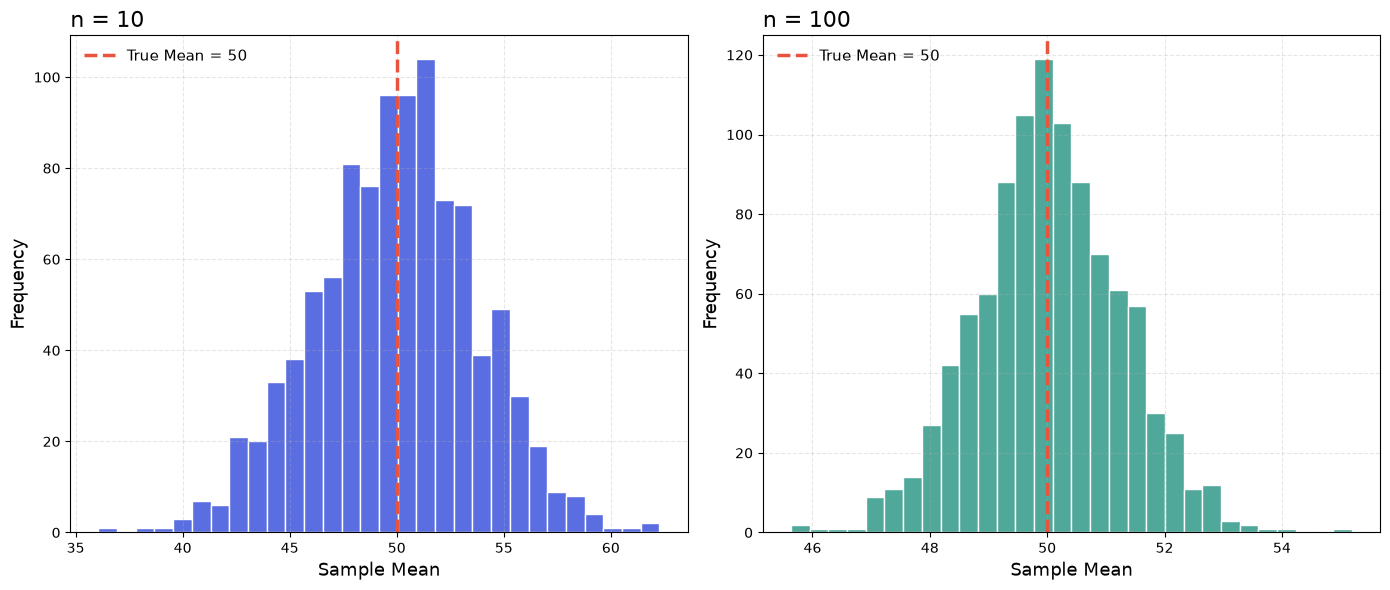

n=10:  mean=49.97, std=3.77, range=(36.1, 62.3)
n=100: mean=50.03, std=1.24, range=(45.6, 55.2)


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Set seed for reproducibility
np.random.seed(42)

# Population parameters
true_mean = 50
population_std = 12  # chosen so n=10 spread ≈ 46-54, n=100 much tighter
n_samples = 1000

def simulate_sample_means(n_obs, pop_mean, pop_std, n_samples):
    """Draw n_samples samples of size n_obs from a normal population
    and return the array of sample means."""
    samples = np.random.normal(pop_mean, pop_std, size=(n_samples, n_obs))
    return samples.mean(axis=1)

# Simulate for small (n=10) and large (n=100) sample sizes
means_small = simulate_sample_means(10, true_mean, population_std, n_samples)
means_large = simulate_sample_means(100, true_mean, population_std, n_samples)

# Create side-by-side histograms
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Left plot: n = 10 ---
axes[0].hist(means_small, bins=30, color="#5B6EE1", edgecolor="white")
axes[0].axvline(true_mean, color="#E8543E", linestyle="--", linewidth=2.5,
                 label=f"True Mean = {true_mean}")
axes[0].set_title("n = 10", fontsize=16, loc="left")
axes[0].set_xlabel("Sample Mean", fontsize=13)
axes[0].set_ylabel("Frequency", fontsize=13)
axes[0].legend(loc="upper left", frameon=False, fontsize=11)
axes[0].grid(axis="both", linestyle="--", alpha=0.3)

# --- Right plot: n = 100 ---
axes[1].hist(means_large, bins=30, color="#4FA89A", edgecolor="white")
axes[1].axvline(true_mean, color="#E8543E", linestyle="--", linewidth=2.5,
                 label=f"True Mean = {true_mean}")
axes[1].set_title("n = 100", fontsize=16, loc="left")
axes[1].set_xlabel("Sample Mean", fontsize=13)
axes[1].set_ylabel("Frequency", fontsize=13)
axes[1].legend(loc="upper left", frameon=False, fontsize=11)
axes[1].grid(axis="both", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.savefig("Plots/sampling_distribution.png", dpi=150)
plt.show()

# Print summary stats
print(f"n=10:  mean={means_small.mean():.2f}, std={means_small.std():.2f}, "
      f"range=({means_small.min():.1f}, {means_small.max():.1f})")
print(f"n=100: mean={means_large.mean():.2f}, std={means_large.std():.2f}, "
      f"range=({means_large.min():.1f}, {means_large.max():.1f})")

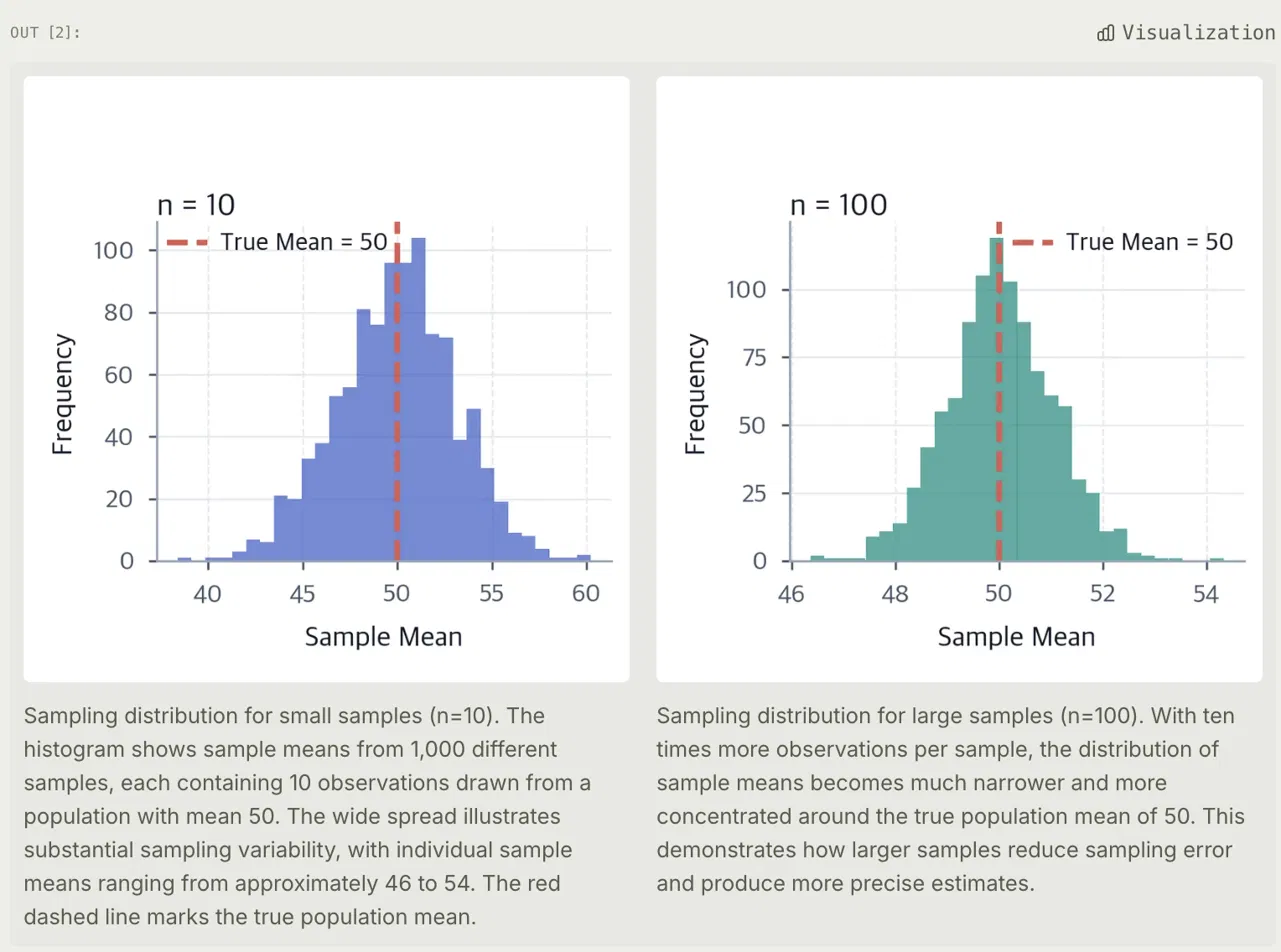

**Examples : Comparing Sampling methods**:

This visualization demonstrates how different sampling strategies can produce samples with varying degrees of representativeness. We'll compare simple random sampling with stratified sampling in a population containing distinct subgroups.


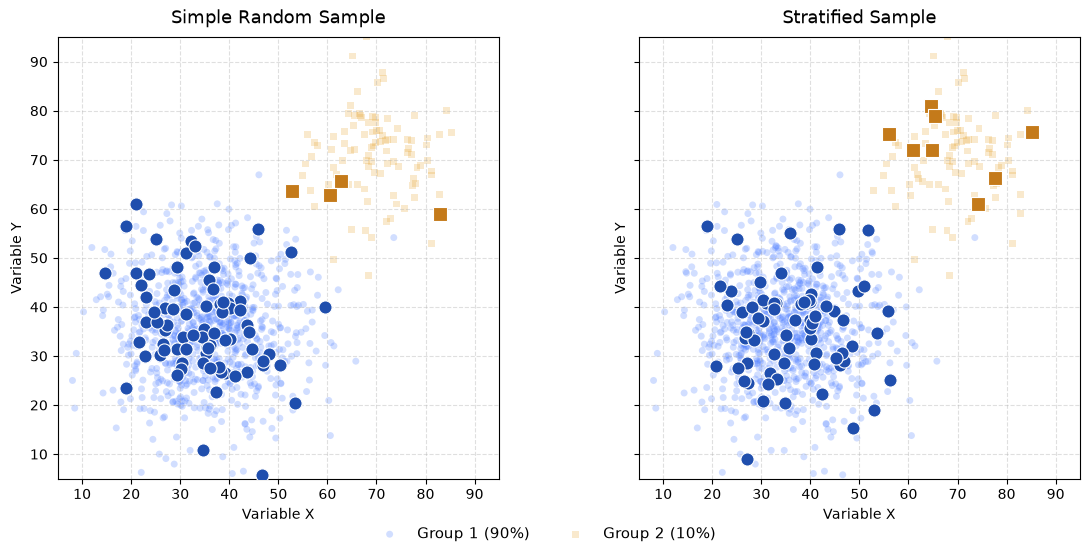

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# -------------------------------------------------
# 1. Generate the population
# -------------------------------------------------
n_group1 = 900   # 90%
n_group2 = 100   # 10%

# Group 1 (blue circles) – dense cloud in lower-left
x1 = np.random.normal(35, 10, n_group1)
y1 = np.random.normal(35, 10, n_group1)

# Group 2 (orange squares) – cloud in upper-right
x2 = np.random.normal(70, 8, n_group2)
y2 = np.random.normal(70, 8, n_group2)

# Combine population
x_pop = np.concatenate([x1, x2])
y_pop = np.concatenate([y1, y2])
group = np.array([0]*n_group1 + [1]*n_group2)   # 0 = Group1, 1 = Group2

# -------------------------------------------------
# 2. Simple Random Sample (may under/over-represent minority)
# -------------------------------------------------
sample_size = 80
srs_idx = np.random.choice(len(x_pop), size=sample_size, replace=False)

# -------------------------------------------------
# 3. Stratified Sample (preserves proportions)
# -------------------------------------------------
# Sample ~90% from Group1 and ~10% from Group2
n1_sample = int(0.9 * sample_size)   # 72
n2_sample = sample_size - n1_sample  # 8

idx_g1 = np.where(group == 0)[0]
idx_g2 = np.where(group == 1)[0]

strat_idx_g1 = np.random.choice(idx_g1, size=n1_sample, replace=False)
strat_idx_g2 = np.random.choice(idx_g2, size=n2_sample, replace=False)
strat_idx = np.concatenate([strat_idx_g1, strat_idx_g2])

# -------------------------------------------------
# 4. Plotting
# -------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), sharex=True, sharey=True)

# Common style
pop_alpha = 0.25
sample_size_marker = 90
pop_size_marker = 25

def plot_panel(ax, title, sample_idx):
    # Population (faded)
    ax.scatter(x1, y1, c='#4A7CFF', s=pop_size_marker, alpha=pop_alpha,
               edgecolors='none', label='Group 1 (90%)')
    ax.scatter(x2, y2, c='#E8A838', s=pop_size_marker, alpha=pop_alpha,
               marker='s', edgecolors='none', label='Group 2 (10%)')

    # Sample (larger, darker, with edge)
    sample_x = x_pop[sample_idx]
    sample_y = y_pop[sample_idx]
    sample_g = group[sample_idx]

    ax.scatter(sample_x[sample_g == 0], sample_y[sample_g == 0],
               c='#1F4EAD', s=sample_size_marker, marker='o',
               edgecolors='white', linewidth=0.8, zorder=5)
    ax.scatter(sample_x[sample_g == 1], sample_y[sample_g == 1],
               c='#C47A1A', s=sample_size_marker, marker='s',
               edgecolors='white', linewidth=0.8, zorder=5)

    ax.set_title(title, fontsize=13, pad=10)
    ax.set_xlabel('Variable X')
    ax.set_ylabel('Variable Y')
    ax.set_xlim(5, 95)
    ax.set_ylim(5, 95)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.set_aspect('equal', adjustable='box')

# Left panel – Simple Random Sample
plot_panel(axes[0], 'Simple Random Sample', srs_idx)

# Right panel – Stratified Sample
plot_panel(axes[1], 'Stratified Sample', strat_idx)

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2,
           bbox_to_anchor=(0.5, -0.02), frameon=False, fontsize=11)

plt.tight_layout()
plt.subplots_adjust(bottom=0.12)
plt.savefig("Plots/Sampling_Comparision.png", dpi=150)
plt.show()

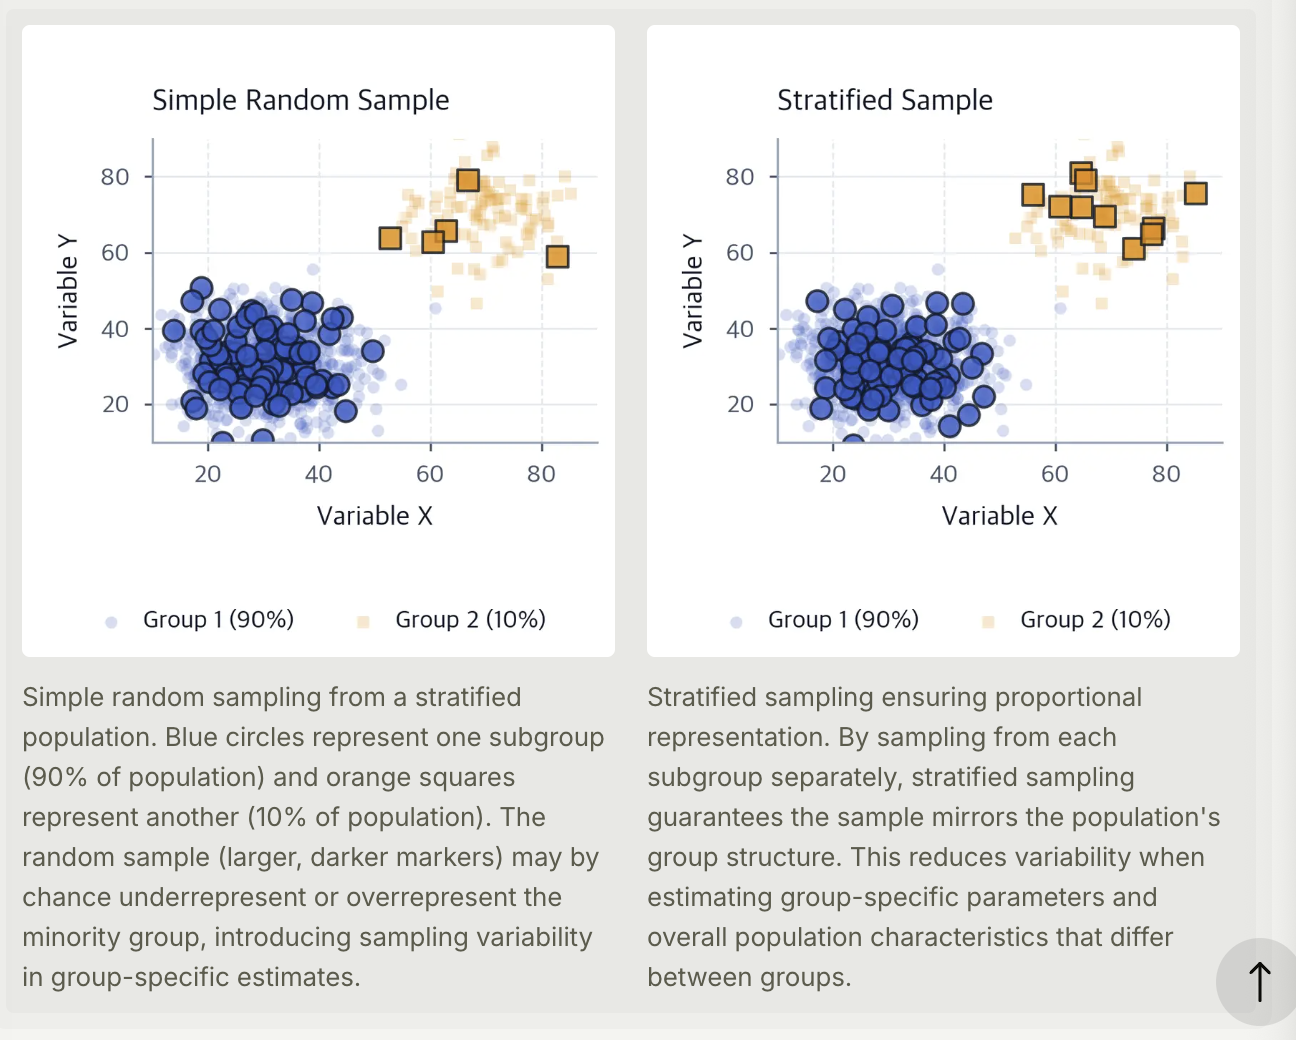

## 5. Practical Applications

Sampling methodologies find application across virtually every domain of data science and statistical analysis. Survey research organizations use stratified sampling to ensure accurate representation of demographic subgroups when polling public opinion, enabling reliable insights from samples of 1,000-2,000 respondents drawn from populations of millions. Market researchers employ cluster sampling when conducting in-person interviews or taste tests, selecting representative cities or neighborhoods rather than attempting to reach randomly selected individuals scattered across vast geographic areas.

In quality control and manufacturing, acceptance sampling determines whether to accept or reject production batches by inspecting random samples of items rather than testing every unit. This approach balances quality assurance needs with testing costs and destructive testing limitations. Clinical trials use careful sampling and randomization to ensure study participants represent broader patient populations, enabling generalizable conclusions about treatment effectiveness from manageable study sizes.

Machine learning practitioners encounter sampling when dividing larger datasets into sets for training and validation, followed by a final test set. Stratified sampling ensures rare classes are adequately represented in each partition, while random sampling helps prevent data leakage and overfitting. When working with massive datasets, data scientists often perform exploratory analysis on carefully drawn samples before committing computational resources to full-dataset analyses.

A/B testing in technology companies relies on random sampling to assign users to experimental conditions. The sampling mechanism directly affects the validity of causal inferences drawn from these experiments.

## 6. Limitation and Considerations

While probability-based sampling provides a rigorous framework for statistical inference, practical implementations face numerous challenges that can compromise the idealized theory. Real-world sampling frames rarely perfectly enumerate the target population. For example, phone survey sampling frames leave out people without phones, and online panels may underrepresent individuals with limited or no access to the internet. Administrative databases can also contain outdated or incomplete information. These coverage gaps mean that even perfectly random selection from a sampling frame may yield biased estimates for the true population of interest.

Nonresponse poses another challenge. When selected individuals decline to participate or cannot be reached, and if these nonrespondents differ systematically from respondents, bias enters the results. Low response rates affect many modern surveys, and weighting adjustments can only partially compensate when the characteristics driving nonresponse are not fully understood or measured.

The law of diminishing returns applies to sample size: doubling sample size reduces standard errors by only about 29% (since standard error decreases with the square root of sample size), while potentially doubling costs. Very large samples reduce sampling error to negligible levels, but this offers little value if non-sampling errors like measurement bias or systematic nonresponse bias dominate. Resources might be better spent improving data quality than simply collecting more observations.

Temporal considerations matter when populations evolve over time. A sample drawn from a customer database represents the population at that moment, but if customer characteristics change, inferences drawn from that sample may not apply to future periods. Trends and seasonal or sudden shifts can all affect the representativeness of samples drawn at specific times.

Sampling theory provides tools for statistical inference but cannot substitute for clear thinking about causal relationships and study design. Representative samples enable us to estimate population characteristics accurately, but they do not by themselves establish causation or ensure that observed associations reflect meaningful relationships rather than confounding factors.



